## Обучение с учителем. Задача классификации. Решающие деревья. Ансамбли моделей

In [ ]:
import pandas as pd
import optuna

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict

### Чтение данных

In [2]:
data = pd.read_csv("../data/credit_card_fraud.csv")
data.head(10)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0
5,5.586408,13.261073,0.064768,1.0,0.0,0.0,0.0,0.0
6,3.724019,0.956838,0.278465,1.0,0.0,0.0,1.0,0.0
7,4.848247,0.320735,1.273050,1.0,0.0,1.0,0.0,0.0
8,0.876632,2.503609,1.516999,0.0,0.0,0.0,0.0,0.0
9,8.839047,2.970512,2.361683,1.0,0.0,0.0,1.0,0.0


### Выделение целевого признака и предиктора

In [4]:
y = data['fraud']
x = data.drop('fraud', axis=1)

### Обучение DecisionTreeClassifier

Включает в себя:
- использование `Pipeline`
- стандартизацию данных при помощи `StandardScaler`
- кросс-валидацию через `KFold`
- подбор гиперпараметров при помощи фреймворка `Optuna`

In [ ]:
def objective(trial):
    params = {
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'splitter': trial.suggest_categorical('splitter', ['best', 'random']),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 5, 25),
        'random_state': 81,
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.01)
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('dtr', DecisionTreeClassifier(**params))
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    score = cross_val_score(
        pipeline, x, y, cv=kf,
        scoring='f1',
        n_jobs=-1
    )

    return score.mean()

In [6]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=-1)

[I 2026-04-10 08:48:01,328] A new study created in memory with name: no-name-7ad52a50-e2e0-410e-a00d-47b718af54f1
[I 2026-04-10 08:48:04,834] Trial 1 finished with value: 0.6816583737540725 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 2, 'min_samples_split': 19, 'min_samples_leaf': 18, 'max_leaf_nodes': 9, 'min_impurity_decrease': 0.03551051891310513, 'ccp_alpha': 0.009826884228833752}. Best is trial 1 with value: 0.6816583737540725.
[I 2026-04-10 08:48:05,591] Trial 0 finished with value: 0.0 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 8, 'min_samples_split': 26, 'min_samples_leaf': 9, 'max_leaf_nodes': 5, 'min_impurity_decrease': 0.09464282042204983, 'ccp_alpha': 0.0020069145035505344}. Best is trial 1 with value: 0.6816583737540725.
[I 2026-04-10 08:48:05,760] Trial 7 finished with value: 0.0 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 9, 'min_samples_split': 26, 'min_samples_leaf': 5, 'max_leaf_

In [7]:
print(f"Best params: {study.best_params}")
print(f"Best f1: {round(study.best_value, 4)}")

Best params: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 7, 'min_samples_split': 22, 'min_samples_leaf': 13, 'max_leaf_nodes': 14, 'min_impurity_decrease': 0.0023923677503951218, 'ccp_alpha': 0.003906534325770219}
Best f1: 0.973


### Метрики

In [26]:
model = DecisionTreeClassifier(**study.best_params, random_state=81)
kf = KFold(n_splits=5, shuffle=True, random_state=81)

y_pred = cross_val_predict(model, x, y, cv=kf, n_jobs=-1)

metrics = {
        "Model": 'DTC Optimized',
        "Accuracy": round(accuracy_score(y, y_pred), 4),
        "Precision": round(precision_score(y, y_pred), 4),
        "Recall": round(recall_score(y, y_pred), 4),
        "F1-Score": round(f1_score(y, y_pred), 4),
        'F1-Score (Optuna)': round(study.best_value, 5),
        "ROC-AUC": round(roc_auc_score(y, y_pred), 4)
    }


In [27]:
res = pd.DataFrame([metrics])
res

,Model,Accuracy,Precision,Recall,F1-Score,F1-Score (Optuna),ROC-AUC
0,DTC Optimized,0.9952,0.9602,0.9861,0.973,0.97301,0.9911


In [28]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    912597
         1.0       0.96      0.99      0.97     87403

    accuracy                           1.00   1000000
   macro avg       0.98      0.99      0.99   1000000
weighted avg       1.00      1.00      1.00   1000000



In [29]:
print(confusion_matrix(y, y_pred))

[[909023   3574]
 [  1217  86186]]


* `Accuracy` = 0.9952 $\rightarrow$ Модель верно предсказала класс для 99.5% объектов всей выборки.
*`Precision` = 0.9602 $\rightarrow$ Из всех случаев, когда модель предсказала «1», она оказалась права в 96% из них.
* `Recall` = 0.9861 $\rightarrow$ Модель успешно нашла 98.6% всех реальных объектов класса «1».
* `F1-Score` = 0.973 $\rightarrow$ Сбалансированная метрика, подтверждающая высокое качество классификации при наличии дисбаланса классов.
* `ROC-AUC` = 0.9911 $\rightarrow$ Свидетельствует о превосходной способности модели разделять классы «0» и «1» (очень близко к идеалу).
* `Macro Avg` $\rightarrow$ Составляет 0.99 для F1-score; это подтверждает, что модель эффективно справляется с обоими классами, несмотря на их разный объем.
* `Confusion Matrix` $\rightarrow$ На 1 000 000 тестов модель допустила всего 4791 ошибку (3574 ложных срабатывания и 1217 пропусков цели).

### Визуализация

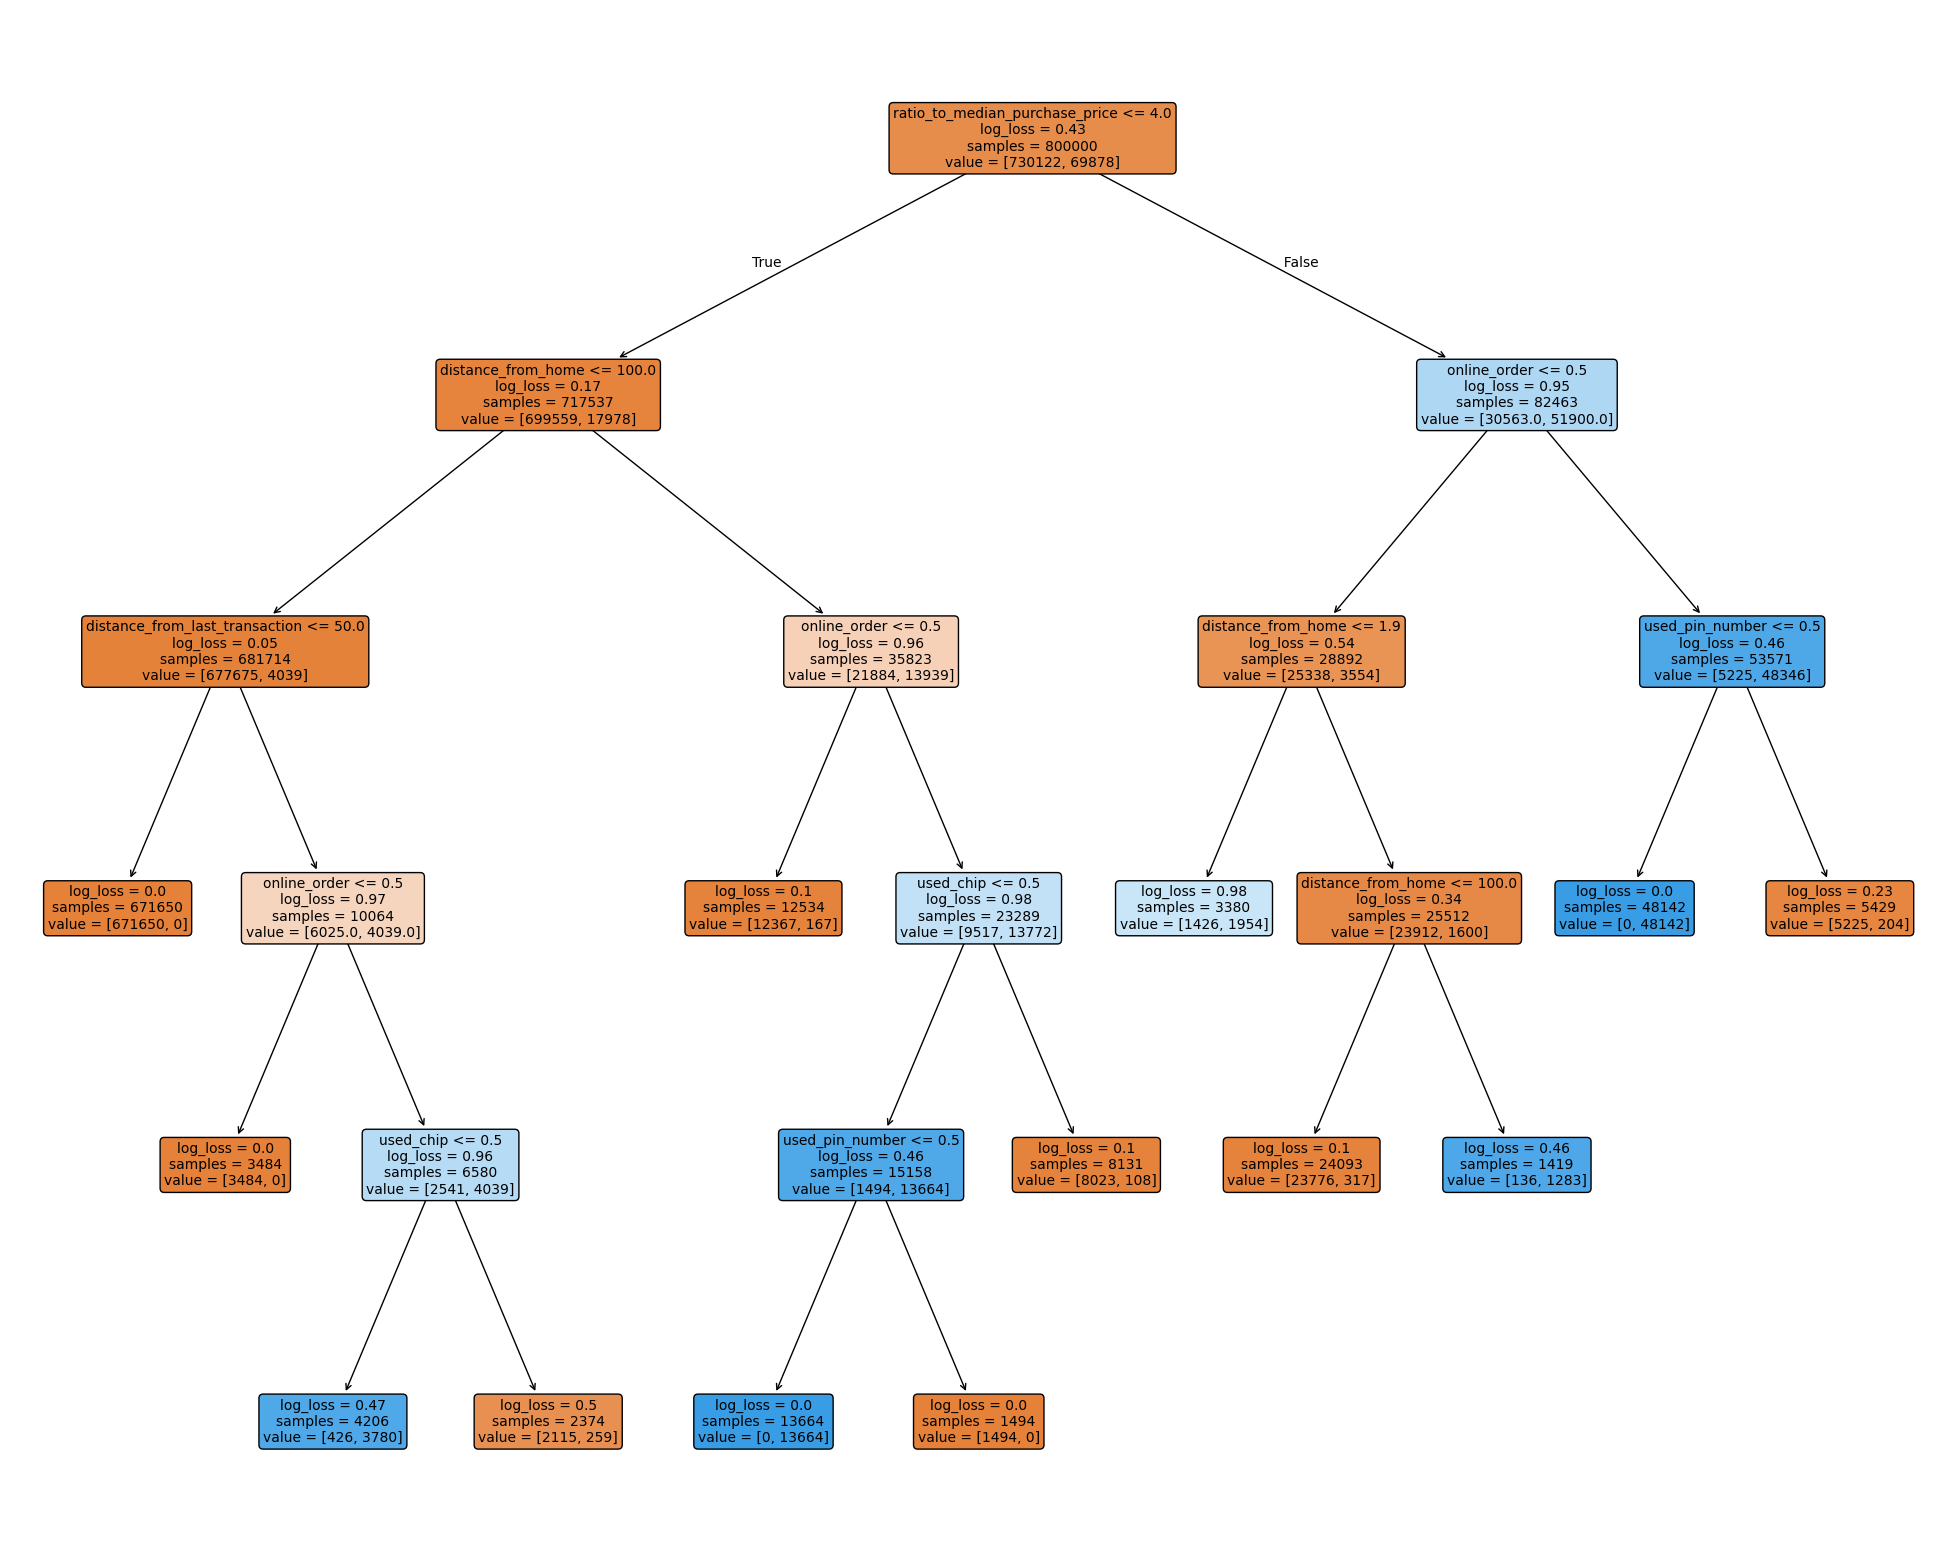

In [12]:
fig = plt.figure(figsize=(25, 20), facecolor='white')
ax = fig.add_subplot(111)

plot_tree(model, 
          feature_names=list(x.columns), 
          filled=True, 
          rounded=True, 
          precision=2, 
          fontsize=10,
          ax=ax)

plt.show()

### Вывод

В ходе выполнения работы была построена и оптимизирована модель классификации на основе решающих деревьев. Использование фреймворка `optuna` и метода кросс-валидации (`K`=5) позволило подобрать гиперпараметры, обеспечивающие высокую точность и устойчивость классификации.

Модель демонстрирует отличную разделяющую способность (согласно метрике `ROC-AUC` = 0.99), успешно минимизируя как ложноположительные, так и ложноотрицательные срабатывания. Высокое значение `f1-Score` (0.973) подтверждает эффективность алгоритма в условиях дисбаланса классов, гарантируя надежное распознавание целевого признака.